In [63]:
import pandas as pd
import scipy.stats as stats
import seaborn as sns, matplotlib.pyplot as plt
import ast
url = "https://raw.githubusercontent.com/nkmwicz/worldcup2018data/refs/heads/main/cleaned_events_world_cup2018.csv"

df=pd.read_csv(url)
df.head(1)

,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2
0,8,Simple pass,['Accurate'],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0


In [64]:
# how does data need to be organized to do a coorelation: 2 numerical columns, and to do an anova we can use catagorical and numerical.
# Anova can have win/loss/draw
# t test is always just gonna be 2 catagories.

In [65]:
df["eventName"].unique()

array(['Pass', 'Duel', 'Free Kick', 'Foul', 'Others on the ball', 'Shot',
       'Save attempt', 'Offside', 'Goalkeeper leaving line'], dtype=object)

In [66]:
df["pass"]=(df["eventName"]=="Pass").astype(int)
df["shot"]=(df["eventName"]=="Shot").astype(int)
df.head(1)
# apply allows us to apply a loop to a series of columns the same way


,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2,pass,shot
0,8,Simple pass,['Accurate'],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0,1,0


In [67]:
df.groupby("matchId").first().reset_index()["matchId"]

0        Argentina - Croatia, 0 - 3
1        Argentina - Iceland, 1 - 1
2           Australia - Peru, 0 - 2
3          Belgium - England, 2 - 0
4            Belgium - Japan, 3 - 2
                  ...              
59         Tunisia - England, 1 - 2
60          Uruguay - France, 0 - 2
61        Uruguay - Portugal, 2 - 1
62          Uruguay - Russia, 3 - 0
63    Uruguay - Saudi Arabia, 1 - 0
Name: matchId, Length: 64, dtype: object

In [68]:
def get_outcome(row):
    teamId=row["teamId"]
    match=row["matchId"]
    teams,scores= match.split(",")
    team1,team2= teams.split(" - ")
    score1, score2 = scores.split(" - ")
    score2=score2.split("(")[0]
    score1=int(score1)
    score2=int(score2)
    if teamId == team1:
        if score1 > score2:
            return "win"
        elif score2 > score1:
            return "loss"
        else:
            return "draw"
    else: # team2 ==teamId
        if score2 > score1:
            return "win"
        elif score1 > score2:
            return "loss"
        else:
            return "draw"
            
df["outcome"]=df.apply(get_outcome, axis=1)


In [69]:
df["outcome"].value_counts()

outcome
win     40517
loss    38867
draw    22375
Name: count, dtype: int64

In [70]:
df.groupby(["matchId","teamId"]).agg({"outcome":"first"}).value_counts()

outcome
loss       51
win        51
draw       26
Name: count, dtype: int64

In [71]:
group_df=df.groupby(["matchId", "teamId"]).agg(
    shots=("shot","sum"),
    passes=("pass", "sum"),
    outcome=("outcome","first"),
).reset_index()
group_df

,matchId,teamId,shots,passes,outcome
0,"Argentina - Croatia, 0 - 3",Argentina,10,476,loss
1,"Argentina - Croatia, 0 - 3",Croatia,13,334,win
2,"Argentina - Iceland, 1 - 1",Argentina,22,744,draw
3,"Argentina - Iceland, 1 - 1",Iceland,8,183,draw
4,"Australia - Peru, 0 - 2",Australia,11,512,loss
...,...,...,...,...,...
123,"Uruguay - Portugal, 2 - 1",Uruguay,6,238,win
124,"Uruguay - Russia, 3 - 0",Russia,3,327,loss
125,"Uruguay - Russia, 3 - 0",Uruguay,12,466,win
126,"Uruguay - Saudi Arabia, 1 - 0",Saudi Arabia,7,553,loss


In [72]:
cats=group_df["outcome"].unique()
pass_samples=[group_df.loc[group_df["outcome"]== c, "passes"]for c in cats]
f,p = stats.f_oneway(*pass_samples)

alpha=0.05
dfb=len(pass_samples)-1
dfw=sum([len(s) for s in pass_samples]) - len(pass_samples) #pass_samples = a list of list -> [[],[],[]]
crit_f=stats.f.ppf(1-alpha,dfb,dfw)

print(f"f={f: 4f}, crit_f={crit_f:4f},p={p:4f}")

f= 2.283776, crit_f=3.068689,p=0.106135


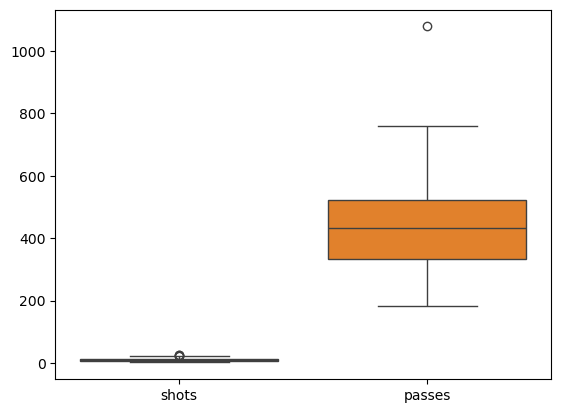

In [73]:
box=sns.boxplot(data=group_df)

In [74]:
p_losers=group_df.loc[group_df["outcome"]== "loss","passes"]
p_n_losers=group_df.loc[group_df["outcome"]!= "loss","passes"]

t,p = stats.ttest_ind(p_losers,p_n_losers)
deg_f=len(p_losers)+ len(p_n_losers)-2
ct=stats.t.ppf(1-alpha/2, deg_f)
print(f"t={t:4f} critical={ct:4f} p={p:.4f}")

t=-1.695128 critical=1.978971 p=0.0925


In [75]:
def run_anova(df, num_col, cat_col):
    """
    Run an Anova on a pandas dataframe on the chosen 
    categorical column and numerical column
    
    Args:
        df (Pandas DataFrame): The pandas DataFrame.
        num_col (str): name of the column of the numerical data.
        cat_col (str): name of the column of the categorical data.
        
    Returns:
        (f, p, critical): the f-stat, p-value, and critical-f    
    """
    cats = df[cat_col].unique()
    samples = [df.loc[df[cat_col] == c, num_col] for c in cats]
    f, p = stats.f_oneway(*samples)

    alpha = 0.05
    dfb = len(samples) - 1 
    dfw = sum([len(s) for s in samples]) - len(samples)
    crit_f = stats.f.ppf(1-alpha, dfb, dfw) # samples = a list of lists => [[],[],[]]
    
    return (f,p,crit_f)

In [76]:
df.groupby(['matchId', 'teamId']).agg({'outcome': 'first'}).value_counts()

outcome
loss       51
win        51
draw       26
Name: count, dtype: int64

In [81]:
group_df = df.groupby(['matchId', 'teamId']).agg(
    shots = ('shot', 'sum'),
    passes = ('pass', 'sum'), 
    outcome = ('outcome', 'first'),
).reset_index()
group_df

,matchId,teamId,shots,passes,outcome
0,"Argentina - Croatia, 0 - 3",Argentina,10,476,loss
1,"Argentina - Croatia, 0 - 3",Croatia,13,334,win
2,"Argentina - Iceland, 1 - 1",Argentina,22,744,draw
3,"Argentina - Iceland, 1 - 1",Iceland,8,183,draw
4,"Australia - Peru, 0 - 2",Australia,11,512,loss
...,...,...,...,...,...
123,"Uruguay - Portugal, 2 - 1",Uruguay,6,238,win
124,"Uruguay - Russia, 3 - 0",Russia,3,327,loss
125,"Uruguay - Russia, 3 - 0",Uruguay,12,466,win
126,"Uruguay - Saudi Arabia, 1 - 0",Saudi Arabia,7,553,loss


In [86]:
x_max = 120
y_max = 75
m3_start = .33 * x_max
a3_start = .66 * x_max
# x2 must be in field loc
def get_loc(x):
    if x < m3_start:
        return "d3"
    elif x < a3_start:
        return "m3"
    else:
        return "a3"

df["field_loc"] = df["x2"].apply(get_loc)
print(m3_start, a3_start)
df.sample(5)[["x2", "field_loc"]]

39.6 79.2


,x2,field_loc
80831,45.0,m3
52299,46.0,m3
7291,41.0,m3
83759,59.0,m3
91234,78.0,m3


In [87]:
df["field_loc"].isna().sum()

np.int64(0)

In [88]:
df["field_loc"].value_counts()

field_loc
m3    51996
d3    34951
a3    14812
Name: count, dtype: int64

In [89]:
dfa3 = df.loc[df["field_loc"] == "a3"]
grp_dfa3 = dfa3.groupby(['matchId', 'teamId']).agg(
    shots = ('shot', 'sum'),
    passes = ('pass', 'sum'), 
    outcome = ('outcome', 'first'),
).reset_index()
f,p,cf = run_anova(grp_dfa3, cat_col="outcome", num_col="passes")
print(f"f={f:.4f}, p={p:.4f}, critical_f={cf:.4f}")

f=0.2297, p=0.7951, critical_f=3.0687
